# SPECTRAX-GK Linear Metric

## What you will learn
How a linear turbulence metric fits into the optimizer while remaining a proxy.

## Codes used
SPECTRAX-GK in research mode; cached growth-rate and frequency curves by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`08_growth_rate_spectrum.png` and `08_frequency_spectrum.png`.

## What this teaches

The object is a linear gyrokinetic screen: growth rate and frequency as early turbulence warnings.

## What this does not prove

It does not prove nonlinear heat flux, profile stiffness, or a validated SPECTRAX-GK result.

## Literature anchor

Linear gyrokinetic spectra are fast warnings, especially when embedded in differentiable or accelerator-ready workflows. SPECTRAX-GK is a JAX-native gyrokinetic solver intended for stellarator optimization workflows, but the public documentation also emphasizes claim scope and validation gates.

Reading: SPECTRAX-GK public package notes, https://pypi.org/project/spectraxgk/.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.turbulence_helpers import growth_rate_spectrum
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
ky, gamma, omega = growth_rate_spectrum()
pd.DataFrame({"ky_rhoi": ky, "gamma": gamma, "omega": omega}).head()

,ky_rhoi,gamma,omega
0,0.050000,-0.018890,0.027200
1,0.076271,-0.014424,0.041251
2,0.102542,-0.008977,0.055137
3,0.128814,-0.002470,0.068856
4,0.155085,0.005154,0.082410


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

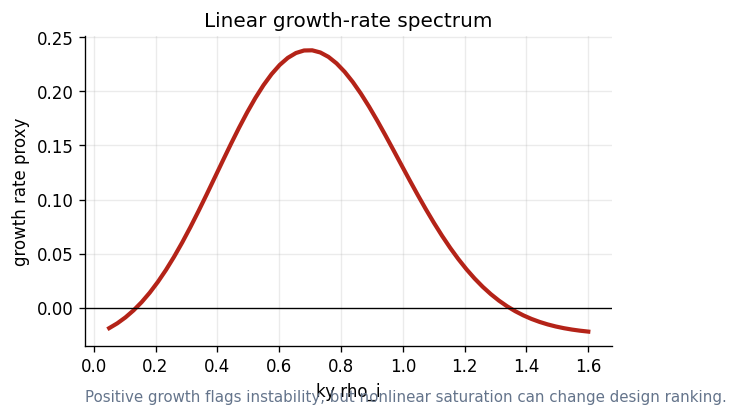

In [7]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(ky, gamma, lw=2.5, color="#b42318")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("ky rho_i")
ax.set_ylabel("growth rate proxy")
ax.set_title("Linear growth-rate spectrum")
ax.grid(alpha=0.25)
caption(ax, "Positive growth flags instability, but nonlinear saturation can change design ranking.")
savefig(fig, "08_growth_rate_spectrum.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

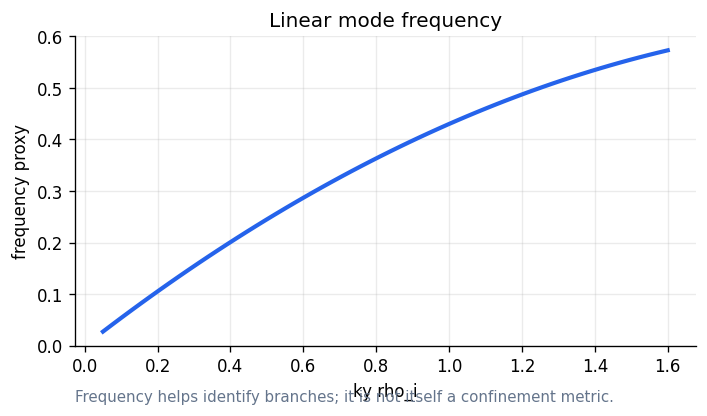

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(ky, omega, lw=2.5, color="#2563eb")
ax.set_xlabel("ky rho_i")
ax.set_ylabel("frequency proxy")
ax.set_title("Linear mode frequency")
ax.grid(alpha=0.25)
caption(ax, "Frequency helps identify branches; it is not itself a confinement metric.")
savefig(fig, "08_frequency_spectrum.png")
plt.show()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
ladder = pd.DataFrame({
    "metric": ["linear gamma", "quasilinear weight", "nonlinear heat flux", "profile prediction"],
    "speed": ["fast", "fast-medium", "slow", "coupled"],
    "trust": ["screen", "ranking hypothesis", "validation", "performance closure"],
})
ladder

,metric,speed,trust
0,linear gamma,fast,screen
1,quasilinear weight,fast-medium,ranking hypothesis
2,nonlinear heat flux,slow,validation
3,profile prediction,coupled,performance closure


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    import spectrax
    print("SPECTRAX import OK:", getattr(spectrax, "__version__", "unknown"))
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

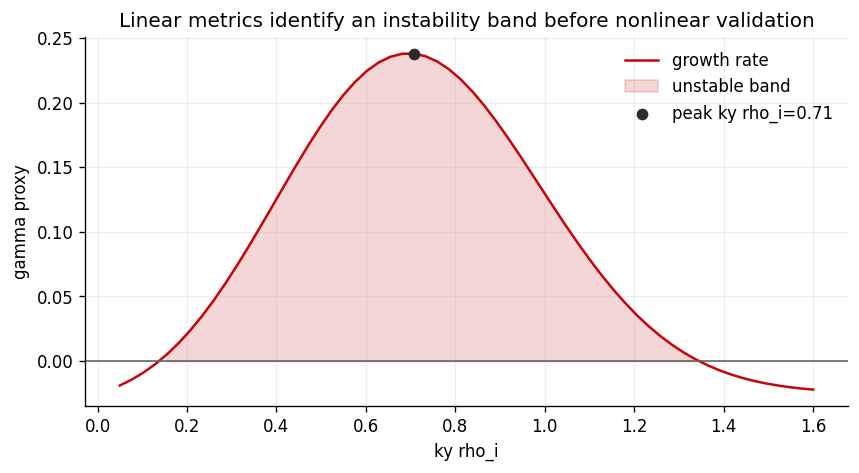

Caption: the unstable band is a screening diagnostic; it does not replace nonlinear heat-flux calculations.


In [13]:
from sos2026.turbulence_helpers import growth_rate_spectrum
ky, gamma, omega = growth_rate_spectrum()
peak = int(np.argmax(gamma))
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(ky, gamma, color="#c5050c", label="growth rate")
ax.fill_between(ky, 0, gamma, where=gamma > 0, color="#c5050c", alpha=0.16, label="unstable band")
ax.scatter([ky[peak]], [gamma[peak]], color="#2b2b2b", zorder=3, label=f"peak ky rho_i={ky[peak]:.2f}")
ax.axhline(0, color="#646569", lw=1)
ax.set_xlabel("ky rho_i")
ax.set_ylabel("gamma proxy")
ax.set_title("Linear metrics identify an instability band before nonlinear validation")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.show()
print("Caption: the unstable band is a screening diagnostic; it does not replace nonlinear heat-flux calculations.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.